--- Initial Data Inspection ---
Sentiment Data Shape: (2644, 4)
Trader Data Shape: (211224, 16)

Missing Values in Trader Data:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

--- Average Daily PnL by Sentiment ---
classification
Extreme Fear     4619.439053
Extreme Greed    5161.922644
Fear             5328.818161
Greed            3318.100730
Neutral          3438.618818
Name: daily_pnl, dtype: float64


C:\Users\Rishabh\AppData\Local\Temp\ipykernel_16960\213726045.py:58: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged_data, x='classification', y='daily_pnl', ci=None)


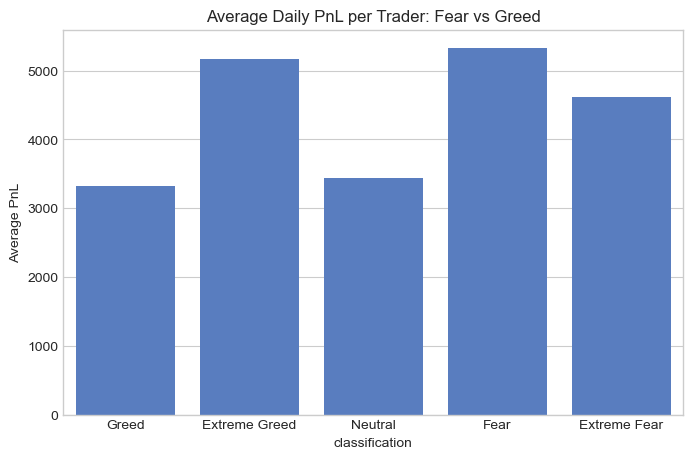

C:\Users\Rishabh\AppData\Local\Temp\ipykernel_16960\213726045.py:72: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged_data, x='classification', y='total_trades', hue='frequency_segment', ci=None, ax=axes)


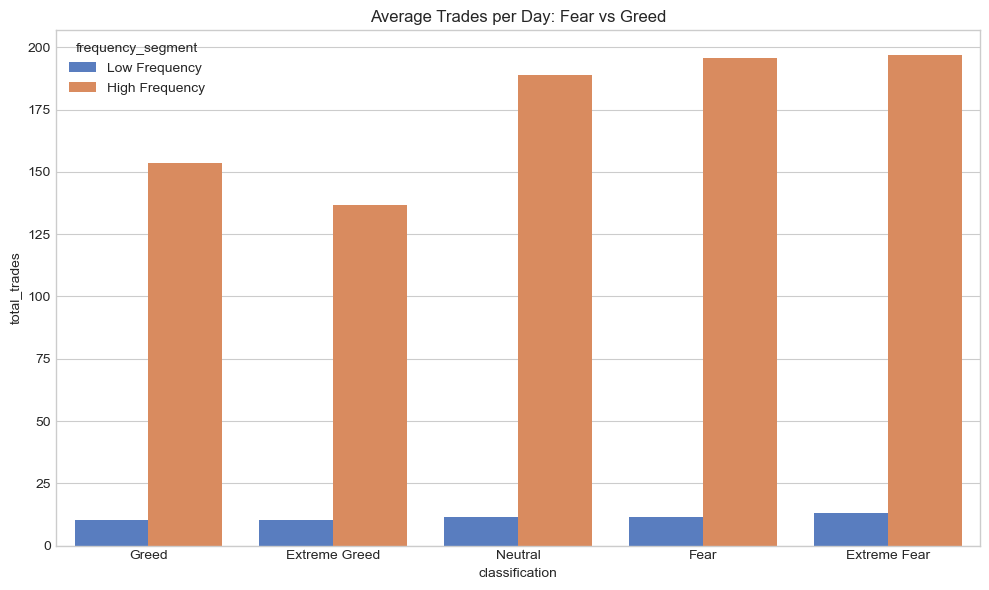


--- Running Predictive Model (Random Forest) ---
Classification Report for Next-Day Profitability:

              precision    recall  f1-score   support

           0       0.65      0.34      0.45       174
           1       0.69      0.89      0.78       288

    accuracy                           0.68       462
   macro avg       0.67      0.61      0.61       462
weighted avg       0.67      0.68      0.65       462


Top Predictors of Next-Day Profitability:
daily_pnl            0.296450
win_rate             0.235451
long_short_ratio     0.233045
total_trades         0.223239
sentiment_numeric    0.011816
dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')




sentiment_df = pd.read_csv("fear_greed_index.csv")
trader_df = pd.read_csv('historical_data.csv')

print("--- Initial Data Inspection ---")
print(f"Sentiment Data Shape: {sentiment_df.shape}")
print(f"Trader Data Shape: {trader_df.shape}\n")
print("Missing Values in Trader Data:\n", trader_df.isna().sum())

# 2. Date Conversion & Alignment
# Sentiment data is likely already daily, but we ensure the format is standard
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.strftime('%Y-%m-%d')

# Trader data is timestamped. We extract the date to align with sentiment
trader_df['time'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
trader_df['date'] = trader_df['time'].dt.strftime('%Y-%m-%d')

# 3. Feature Engineering: Create Daily Metrics per Account
# We group by Date and Account to calculate daily performance and behavior
daily_trader_metrics = trader_df.groupby(['date', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    total_trades=('Trade ID', 'count'),
    # Win rate: Percentage of trades where PnL > 0
    win_rate=('Closed PnL', lambda x: (x > 0).mean()),
    # Count buys and sells to calculate Long/Short ratio later
    long_trades=('Side', lambda x: (x == 'BUY').sum()),
    short_trades=('Side', lambda x: (x == 'SELL').sum())
).reset_index()

# Calculate Long/Short Ratio (Adding a tiny number 1e-9 to avoid division by zero)
daily_trader_metrics['long_short_ratio'] = daily_trader_metrics['long_trades'] / (daily_trader_metrics['short_trades'] + 1e-9)

# 4. Merge Datasets
# Left join ensures we keep all trading days, even if sentiment data is missing for a day
merged_data = pd.merge(daily_trader_metrics, sentiment_df, left_on='date', right_on='date', how='left')

merged_data.dropna(subset=['classification'], inplace=True) # Drop days without sentiment

# 1. Overall Performance: Fear vs. Greed
print("\n--- Average Daily PnL by Sentiment ---")
print(merged_data.groupby('classification')['daily_pnl'].mean())

plt.figure(figsize=(8, 5))
sns.barplot(data=merged_data, x='classification', y='daily_pnl', ci=None)
plt.title('Average Daily PnL per Trader: Fear vs Greed')
plt.ylabel('Average PnL')
plt.show()

# 2. Trader Segmentation
# Segment Analysis: Trade Frequency
median_trades = merged_data['total_trades'].median()
merged_data['frequency_segment'] = np.where(merged_data['total_trades'] > median_trades, 'High Frequency', 'Low Frequency')

# 3. Visualizing Segments across Market Sentiment
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Plot: Trade Frequency by Sentiment
sns.barplot(data=merged_data, x='classification', y='total_trades', hue='frequency_segment', ci=None, ax=axes)
axes.set_title('Average Trades per Day: Fear vs Greed')
plt.tight_layout()
plt.show()


# ==========================================
# BONUS: PREDICTIVE MODEL (Next-Day Profitability)
# ==========================================
print("\n--- Running Predictive Model (Random Forest) ---")

# We want to predict if a trader will be profitable the *next* day based on today's sentiment & behavior.
# Shift the PnL by -1 within each account to get the next day's PnL
merged_data = merged_data.sort_values(by=['Account', 'date'])
merged_data['next_day_pnl'] = merged_data.groupby('Account')['daily_pnl'].shift(-1)

# Drop the last day for each trader since we can't see their "next day"
model_data = merged_data.dropna(subset=['next_day_pnl']).copy()

# Target Variable: 1 if profitable next day, 0 if not
model_data['target_profitable'] = (model_data['next_day_pnl'] > 0).astype(int)

# Features: Today's behavior and sentiment
# Convert Sentiment to numeric (1 for Greed, 0 for Fear)
model_data['sentiment_numeric'] = np.where(model_data['classification'] == 'Greed', 1, 0)

features = ['total_trades', 'win_rate', 'long_short_ratio', 'sentiment_numeric', 'daily_pnl']
X = model_data[features]
y = model_data['target_profitable']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = rf_model.predict(X_test)
print("Classification Report for Next-Day Profitability:\n")
print(classification_report(y_test, y_pred))

# Feature Importance to drive "Actionable Output"
feature_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop Predictors of Next-Day Profitability:")
print(feature_imp)